# Metodo otsu

En el procesamiento de imágenes , el método de Otsu , llamado así por Nobuyuki Otsu, se utiliza para realizar la determinación automática del umbral de la imagen. En su forma más simple, el algoritmo devuelve un único umbral de intensidad que separa los píxeles en dos clases, primer plano y fondo. Este umbral se determina minimizando la varianza de intensidad intraclase o, equivalentemente, maximizando la varianza interclase. El método de Otsu es un análogo discreto unidimensional del análisis discriminante de Fisher, está relacionado con el método de optimización de Jenks y es equivalente a una k-media globalmente óptima realizada en el histograma de intensidad. La extensión a la determinación del umbral de varios niveles se describió en el artículo original y desde entonces se han propuesto implementaciones computacionalmente eficientes.

/var/folders/p5/9q_ff1ts34z4t_mrnn9362xh0000gn/T/ipykernel_55879/785333774.py:70: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.flatten(), 256, [0, 256], color='gray')


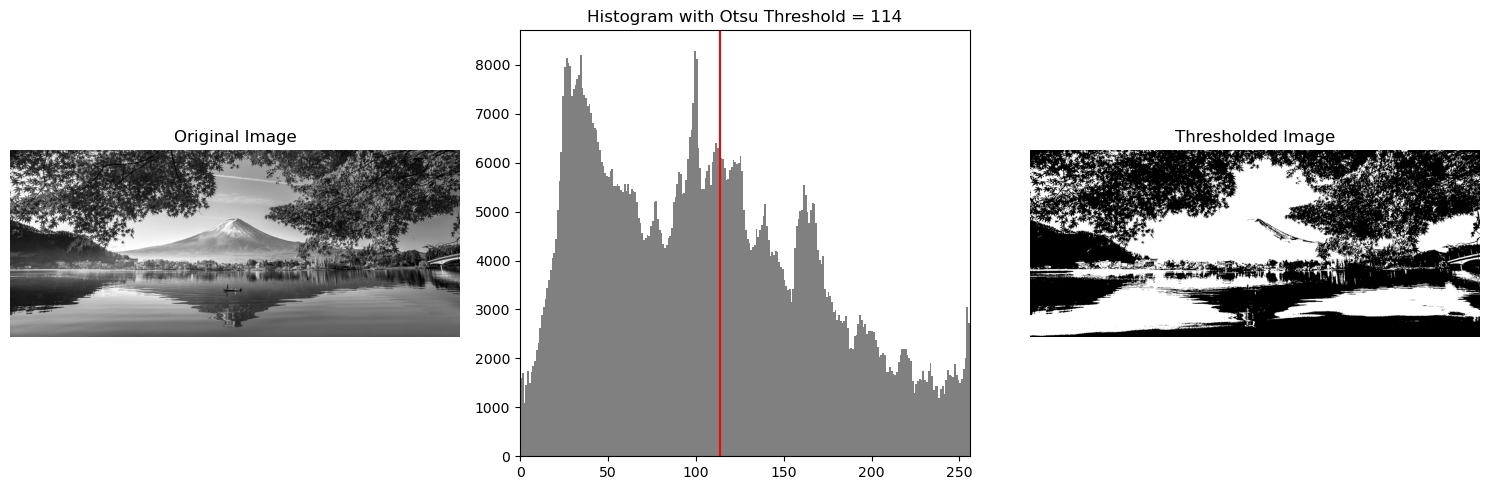

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def otsu_threshold(image):
    # Calculate histogram
    hist, bins = np.histogram(image.flatten(), bins=256, range=[0, 256])
    
    # Total number of pixels
    total_pixels = image.size
    
    # Initialize variables
    sum_total = 0
    for i in range(256):
        sum_total += i * hist[i]
    
    # Variables for background and foreground weights and means
    weight_bg = 0
    weight_fg = 0
    sum_bg = 0
    
    max_variance = 0
    threshold = 0
    
    # Iterate through all possible threshold values
    for t in range(256):
        # Update weights
        weight_bg += hist[t]
        if weight_bg == 0:
            continue
            
        weight_fg = total_pixels - weight_bg
        if weight_fg == 0:
            break
            
        # Update means
        sum_bg += t * hist[t]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        
        # Calculate between-class variance
        variance = weight_bg * weight_fg * (mean_bg - mean_fg)**2
        
        # Update threshold if variance is greater
        if variance > max_variance:
            max_variance = variance
            threshold = t
    
    return threshold

# Load image in grayscale
image = cv2.imread('./images/1.jpeg', 0)

# Apply our manual Otsu thresholding
otsu_value = otsu_threshold(image)
_, binary_image = cv2.threshold(image, otsu_value, 255, cv2.THRESH_BINARY)

# Display results
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

# Histogram with threshold marked
plt.subplot(1, 3, 2)
plt.title(f'Histogram with Otsu Threshold = {otsu_value}')
plt.hist(image.flatten(), 256, [0, 256], color='gray')
plt.axvline(otsu_value, color='red')
plt.xlim([0, 256])

# Binary image
plt.subplot(1, 3, 3)
plt.title('Thresholded Image')
plt.imshow(binary_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()